# Лабораторная работа 3

**Тема:** методы многомерного поиска.

Вариант 1: `a = 50`, `b = 2`, `f0 = 10`, `n = 2`. Минимизируем тестовую функцию Розенброка методами Флетчера-Ривза, Полака-Рибьера, DFP, BFGS и L-BFGS.

In [1]:
import importlib.util
import subprocess
import sys


def ensure(package, import_name=None):
    import_name = import_name or package
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

for package, import_name in [('numpy', 'numpy'), ('pandas', 'pandas'), ('matplotlib', 'matplotlib')]:
    ensure(package, import_name)

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

A = 50.0
B = 2.0
F0 = 10.0
N = 2
x0 = np.array([-1.2, 1.0], dtype=float)

In [2]:
def rosenbrock(x, a=A, b=B, f0=F0):
    x = np.asarray(x, dtype=float)
    return f0 + sum(a * (x[i + 1] - x[i] ** 2) ** 2 + b * (1 - x[i]) ** 2 for i in range(len(x) - 1))


def rosenbrock_grad(x, a=A, b=B):
    x = np.asarray(x, dtype=float)
    g = np.zeros_like(x)
    for i in range(len(x) - 1):
        t = x[i + 1] - x[i] ** 2
        g[i] += -4 * a * x[i] * t - 2 * b * (1 - x[i])
        g[i + 1] += 2 * a * t
    return g


def armijo_line_search(func, grad_func, x, d, alpha0=1.0, c=1e-4, tau=0.5, max_iter=80):
    fx = func(x)
    g = grad_func(x)
    directional = float(g @ d)
    if directional >= 0:
        return 0.0
    alpha = alpha0
    for _ in range(max_iter):
        if func(x + alpha * d) <= fx + c * alpha * directional:
            return alpha
        alpha *= tau
    return alpha

print('Стационарная точка:', np.ones(N))
print('Значение функции в ней:', rosenbrock(np.ones(N)))

Стационарная точка: [1. 1.]
Значение функции в ней: 10.0


In [3]:
def nonlinear_conjugate_gradient(kind, max_iter=10_000, tol=1e-6):
    x = x0.copy()
    g = rosenbrock_grad(x)
    d = -g
    history = []
    started = time.perf_counter()

    for k in range(max_iter):
        history.append({'iter': k, 'x1': x[0], 'x2': x[1], 'f': rosenbrock(x), 'grad_norm': np.linalg.norm(g)})
        if np.linalg.norm(g) < tol:
            break
        if g @ d >= 0:
            d = -g
        alpha = armijo_line_search(rosenbrock, rosenbrock_grad, x, d)
        if alpha == 0:
            d = -g
            alpha = armijo_line_search(rosenbrock, rosenbrock_grad, x, d)
        x_next = x + alpha * d
        g_next = rosenbrock_grad(x_next)

        if kind == 'Fletcher-Reeves':
            beta = (g_next @ g_next) / (g @ g + 1e-30)
        elif kind == 'Polak-Ribiere':
            beta = max(0.0, (g_next @ (g_next - g)) / (g @ g + 1e-30))
        else:
            raise ValueError(kind)

        d = -g_next + beta * d
        x, g = x_next, g_next

    return {
        'method': kind,
        'x': x,
        'f': rosenbrock(x),
        'grad_norm': np.linalg.norm(g),
        'iterations': len(history),
        'time_sec': time.perf_counter() - started,
        'history': pd.DataFrame(history),
    }

In [4]:
def quasi_newton(kind, max_iter=10_000, tol=1e-6):
    x = x0.copy()
    g = rosenbrock_grad(x)
    H = np.eye(N)
    history = []
    started = time.perf_counter()

    for k in range(max_iter):
        history.append({'iter': k, 'x1': x[0], 'x2': x[1], 'f': rosenbrock(x), 'grad_norm': np.linalg.norm(g)})
        if np.linalg.norm(g) < tol:
            break
        d = -H @ g
        if g @ d >= 0:
            H = np.eye(N)
            d = -g
        alpha = armijo_line_search(rosenbrock, rosenbrock_grad, x, d)
        x_next = x + alpha * d
        g_next = rosenbrock_grad(x_next)
        s = x_next - x
        y = g_next - g
        sy = float(s @ y)

        if sy > 1e-12:
            if kind == 'DFP':
                Hy = H @ y
                yHy = float(y @ Hy)
                if yHy > 1e-12:
                    H = H + np.outer(s, s) / sy - np.outer(Hy, Hy) / yHy
            elif kind == 'BFGS':
                rho = 1.0 / sy
                I = np.eye(N)
                V = I - rho * np.outer(s, y)
                H = V @ H @ V.T + rho * np.outer(s, s)
            else:
                raise ValueError(kind)

        x, g = x_next, g_next

    return {
        'method': kind,
        'x': x,
        'f': rosenbrock(x),
        'grad_norm': np.linalg.norm(g),
        'iterations': len(history),
        'time_sec': time.perf_counter() - started,
        'history': pd.DataFrame(history),
    }

In [5]:
def lbfgs(memory=7, max_iter=10_000, tol=1e-6):
    x = x0.copy()
    g = rosenbrock_grad(x)
    pairs = []
    history = []
    started = time.perf_counter()

    for k in range(max_iter):
        history.append({'iter': k, 'x1': x[0], 'x2': x[1], 'f': rosenbrock(x), 'grad_norm': np.linalg.norm(g)})
        if np.linalg.norm(g) < tol:
            break

        q = g.copy()
        alphas = []
        for s, y in reversed(pairs):
            rho = 1.0 / (y @ s)
            alpha = rho * (s @ q)
            alphas.append(alpha)
            q = q - alpha * y

        if pairs:
            s_last, y_last = pairs[-1]
            gamma = (s_last @ y_last) / (y_last @ y_last)
        else:
            gamma = 1.0

        r = gamma * q
        for (s, y), alpha in zip(pairs, reversed(alphas)):
            rho = 1.0 / (y @ s)
            beta = rho * (y @ r)
            r = r + s * (alpha - beta)

        d = -r
        if g @ d >= 0:
            d = -g
            pairs = []

        alpha = armijo_line_search(rosenbrock, rosenbrock_grad, x, d)
        x_next = x + alpha * d
        g_next = rosenbrock_grad(x_next)
        s = x_next - x
        y = g_next - g

        if s @ y > 1e-12:
            pairs.append((s, y))
            pairs = pairs[-memory:]

        x, g = x_next, g_next

    return {
        'method': 'L-BFGS',
        'x': x,
        'f': rosenbrock(x),
        'grad_norm': np.linalg.norm(g),
        'iterations': len(history),
        'time_sec': time.perf_counter() - started,
        'history': pd.DataFrame(history),
    }

In [6]:
results = [
    nonlinear_conjugate_gradient('Fletcher-Reeves'),
    nonlinear_conjugate_gradient('Polak-Ribiere'),
    quasi_newton('DFP'),
    quasi_newton('BFGS'),
    lbfgs(memory=7),
]

summary = pd.DataFrame([{k: v for k, v in result.items() if k != 'history'} for result in results])
summary['x'] = summary['x'].apply(lambda x: np.round(x, 8))
summary[['method', 'x', 'f', 'grad_norm', 'iterations', 'time_sec']].round(8)

,method,x,f,grad_norm,iterations,time_sec
0,Fletcher-Reeves,"[0.99999979, 0.99999958]",10.0,3.900000e-07,250,0.009144
1,Polak-Ribiere,"[0.99999993, 0.99999987]",10.0,9.800000e-07,728,0.021424
2,DFP,"[1.0, 1.0]",10.0,6.000000e-08,30,0.000683
3,BFGS,"[1.0, 1.0]",10.0,1.000000e-08,25,0.000524
4,L-BFGS,"[0.99999999, 0.99999999]",10.0,6.000000e-08,31,0.001174


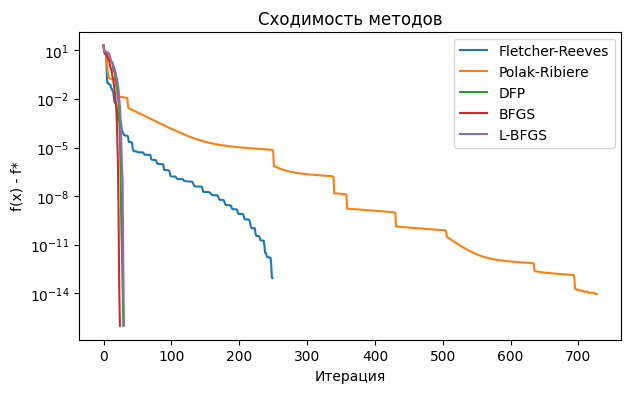

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
for result in results:
    h = result['history']
    ax.semilogy(h['iter'], h['f'] - F0 + 1e-16, label=result['method'])
ax.set_xlabel('Итерация')
ax.set_ylabel('f(x) - f*')
ax.set_title('Сходимость методов')
ax.legend()
plt.show()

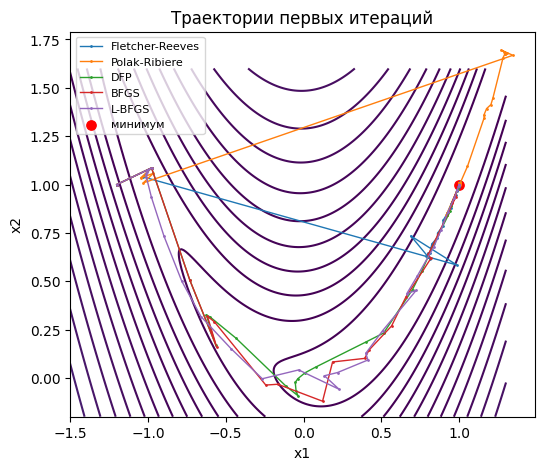

In [8]:
x1 = np.linspace(-1.5, 1.3, 220)
x2 = np.linspace(-0.2, 1.6, 220)
X1, X2 = np.meshgrid(x1, x2)
Z = F0 + A * (X2 - X1 ** 2) ** 2 + B * (1 - X1) ** 2

fig, ax = plt.subplots(figsize=(6, 5))
ax.contour(X1, X2, Z, levels=np.logspace(1, 3.5, 24), cmap='viridis')
for result in results:
    h = result['history'].iloc[:120]
    ax.plot(h['x1'], h['x2'], marker='.', markersize=2, linewidth=1, label=result['method'])
ax.scatter([1], [1], c='red', s=45, label='минимум')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('Траектории первых итераций')
ax.legend(fontsize=8)
plt.show()